In [ ]:
!nvidia-smi

Mon Mar  2 04:02:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip -q install tensorflow opencv-python numpy pandas matplotlib scikit-learn tqdm

In [ ]:
import os, glob, random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

Set seeds (reproducible)

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(sayem, "**", ext), recursive=True)

def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice","icteric","positive","pos","case","patient","affected","yellow"]
    neg_keys = ["normal","control","negative","neg","healthy","non"]
    if any(k in lp for k in pos_keys): return 1
    if any(k in lp for k in neg_keys): return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p,l) for p,l in pairs if l is not None]

print("Total labeled:", len(pairs))
print("Class counts:", np.bincount([l for _,l in pairs]))
print("Sample:", pairs[:3])

Total labeled: 760
Class counts: [560 200]
Sample: [('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', 0)]


Forehead ROI crop function

In [ ]:
def extract_forehead_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)
    y1 = int(0.10 * h)
    y2 = int(0.40 * h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

Create ROI image dataset folders (train/val/test)

In [ ]:
OUT_ROOT = "/content/NJN_DL_Forehead_V1"
for split in ["train","val","test"]:
    for c in ["0","1"]:
        os.makedirs(os.path.join(OUT_ROOT, split, c), exist_ok=True)

# split: 70/15/15 (stratified)
paths = [p for p,_ in pairs]
labels = np.array([l for _,l in pairs])

train_p, temp_p, train_y, temp_y = train_test_split(
    paths, labels, test_size=0.30, random_state=SEED, stratify=labels
)
val_p, test_p, val_y, test_y = train_test_split(
    temp_p, temp_y, test_size=0.50, random_state=SEED, stratify=temp_y
)

print("Split sizes:", len(train_p), len(val_p), len(test_p))
print("Train dist:", np.bincount(train_y), "Val dist:", np.bincount(val_y), "Test dist:", np.bincount(test_y))

Split sizes: 532 114 114
Train dist: [392 140] Val dist: [84 30] Test dist: [84 30]


Save ROI crops into split folders

In [ ]:
IMG_SIZE = 224

def save_roi_images(paths, labels, split_name):
    failed = 0
    for p, y in tqdm(list(zip(paths, labels)), desc=f"Saving {split_name}"):
        img = cv2.imread(p)
        if img is None:
            failed += 1
            continue
        roi = extract_forehead_roi(img)
        if roi is None:
            failed += 1
            continue
        roi = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
        out_path = os.path.join(OUT_ROOT, split_name, str(int(y)), os.path.basename(p))
        cv2.imwrite(out_path, roi)
    return failed

failed_train = save_roi_images(train_p, train_y, "train")
failed_val   = save_roi_images(val_p, val_y, "val")
failed_test  = save_roi_images(test_p, test_y, "test")

print("Failed counts:", failed_train, failed_val, failed_test)

Saving test: 100%|██████████| 114/114 [00:01<00:00, 79.28it/s]

Failed counts: 0 0 0


Data loaders (tf.data) + Augmentation

In [ ]:
BATCH = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(OUT_ROOT,"train"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode="binary",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(OUT_ROOT,"val"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode="binary",
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(OUT_ROOT,"test"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode="binary",
    shuffle=False
)

# Normalize + augmentation
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

def prep(ds, training=False):
    ds = ds.map(lambda x,y: (tf.cast(x, tf.float32)/255.0, y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x,y: (data_aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(512, seed=SEED)
    return ds.prefetch(AUTOTUNE)

train_ds_p = prep(train_ds, training=True)
val_ds_p   = prep(val_ds, training=False)
test_ds_p  = prep(test_ds, training=False)

Found 532 files belonging to 2 classes.
Found 114 files belonging to 2 classes.
Found 114 files belonging to 2 classes.


Class weights (imbalance handle)

In [ ]:
# compute weights from train_y
n0 = np.sum(train_y==0)
n1 = np.sum(train_y==1)
total = n0 + n1
class_weight = {
    0: total/(2*n0),
    1: total/(2*n1)
}
print("class_weight:", class_weight)

class_weight: {0: np.float64(0.6785714285714286), 1: np.float64(1.9)}


Build model (EfficientNetB0 Transfer Learning)

In [ ]:
base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False  # first stage: freeze

inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inp, out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Train (Stage-1 frozen) + callbacks

In [ ]:
ckpt_path = "/content/forehead_effnet_best.keras"
cbs = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
]

history1 = model.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=20,
    class_weight=class_weight,
    callbacks=cbs
)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.6826 - loss: 0.6904 - val_accuracy: 0.2632 - val_loss: 0.7070 - learning_rate: 2.5000e-04
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.4467 - loss: 0.6772 - val_accuracy: 0.2632 - val_loss: 0.6993 - learning_rate: 2.5000e-04
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.4635 - loss: 0.6918 - val_accuracy: 0.7368 - val_loss: 0.6876 - learning_rate: 2.5000e-04
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.4671 - loss: 0.7134 - val_accuracy: 0.7368 - val_loss: 0.6905 - learning_rate: 2.5000e-04
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4615 - loss: 0.7335 - val_accuracy: 0.7368 - val_loss: 0.6808 - learning_rate: 2.5000e-04
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.5762 - loss: 0.7104 - val_accuracy: 0.7368 - val_loss: 0.6831 - learning_rate: 2.5000e-04
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.6583

Fine-tune (Stage-2: unfreeze last blocks)

In [ ]:
base.trainable = True

# Freeze early layers, unfreeze last ~30% layers
cut = int(len(base.layers) * 0.70)
for i, layer in enumerate(base.layers):
    layer.trainable = (i >= cut)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=15,
    class_weight=class_weight,
    callbacks=cbs
)

Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 76s 937ms/step - accuracy: 0.5356 - loss: 0.7244 - val_accuracy: 0.2632 - val_loss: 0.7079 - learning_rate: 1.0000e-04
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.5420 - loss: 0.7389 - val_accuracy: 0.2632 - val_loss: 0.7190 - learning_rate: 1.0000e-04
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.5240 - loss: 0.7235 - val_accuracy: 0.2632 - val_loss: 0.7150 - learning_rate: 1.0000e-04
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.5512 - loss: 0.6944 - val_accuracy: 0.2632 - val_loss: 0.6998 - learning_rate: 5.0000e-05
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.5517 - loss: 0.7036 - val_accuracy: 0.7193 - val_loss: 0.6893 - learning_rate: 5.0000e-05
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.4443 - loss: 0.7682 - val_accuracy: 0.7368 - val_loss: 0.6769 - learning_rate: 5.0000e-05
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.59

Plot training curves (Accuracy + Loss)

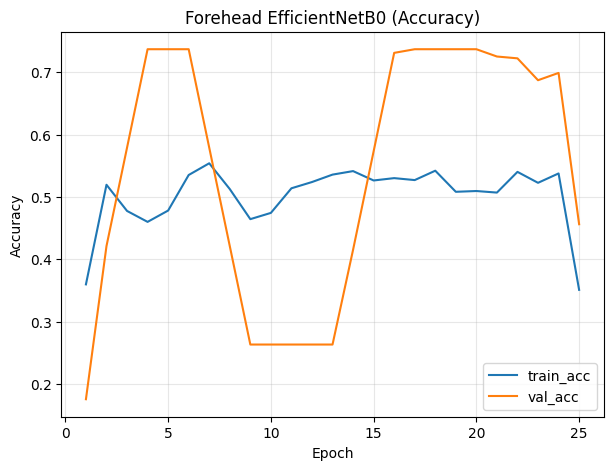

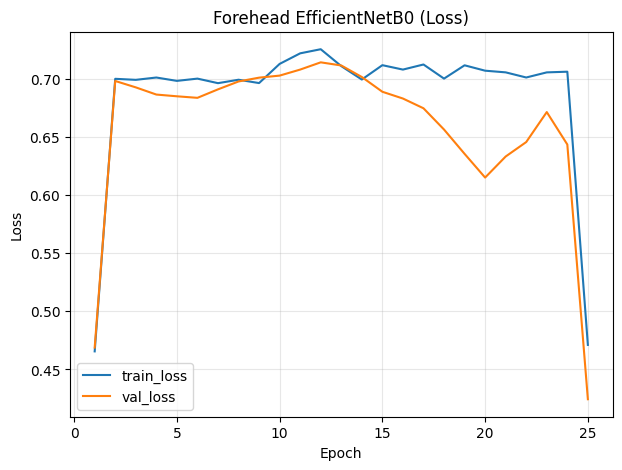

In [ ]:
def smooth_curve(x, k=5):
    x = np.array(x, dtype=float)
    if len(x) < k:
        return x
    out = np.convolve(x, np.ones(k)/k, mode="same")
    return out

def plot_history(histories, title="Training Curves", smooth_k=5):
    # merge histories
    acc = []
    val_acc = []
    loss = []
    val_loss = []
    for h in histories:
        acc += h.history.get("accuracy", [])
        val_acc += h.history.get("val_accuracy", [])
        loss += h.history.get("loss", [])
        val_loss += h.history.get("val_loss", [])
    epochs = np.arange(1, len(acc)+1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, smooth_curve(acc, smooth_k), label="train_acc")
    plt.plot(epochs, smooth_curve(val_acc, smooth_k), label="val_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(title + " (Accuracy)")
    plt.grid(alpha=0.3); plt.legend()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(epochs, smooth_curve(loss, smooth_k), label="train_loss")
    plt.plot(epochs, smooth_curve(val_loss, smooth_k), label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title + " (Loss)")
    plt.grid(alpha=0.3); plt.legend()
    plt.show()

plot_history([history1, history2], title="Forehead EfficientNetB0", smooth_k=3)

Test evaluation (Accuracy + report + confusion matrix)

8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 932ms/step
Test classification report:

              precision    recall  f1-score   support

         0.0      0.737     1.000     0.848        84
         1.0      0.000     0.000     0.000        30

    accuracy                          0.737       114
   macro avg      0.368     0.500     0.424       114
weighted avg      0.543     0.737     0.625       114

Confusion Matrix:
 [[84  0]
 [30  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


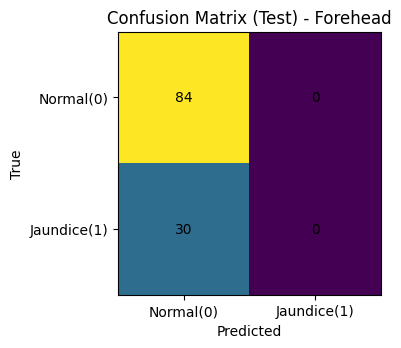

In [ ]:
# Predict probabilities on test set
y_true = np.concatenate([y.numpy().ravel() for _,y in test_ds])
y_prob = model.predict(test_ds_p).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Test classification report:\n")
print(classification_report(y_true, y_pred, digits=3))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("Confusion Matrix (Test) - Forehead")
plt.xticks([0,1], ["Normal(0)","Jaundice(1)"])
plt.yticks([0,1], ["Normal(0)","Jaundice(1)"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()

Test AUC: 0.626984126984127


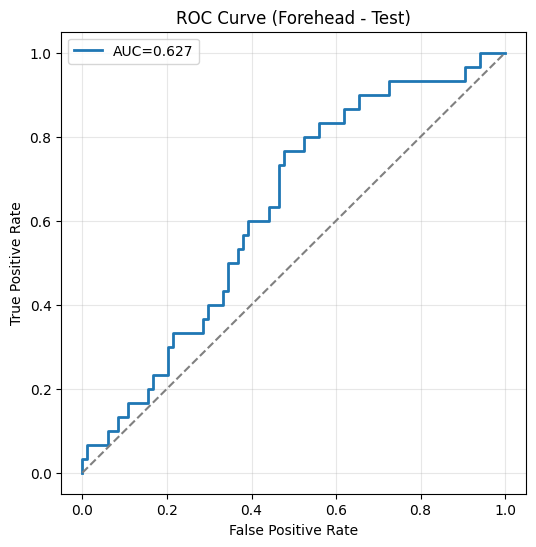

In [ ]:
fpr, tpr, thr = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
print("Test AUC:", roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Forehead - Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Average Precision (AP): 0.3693380015147898


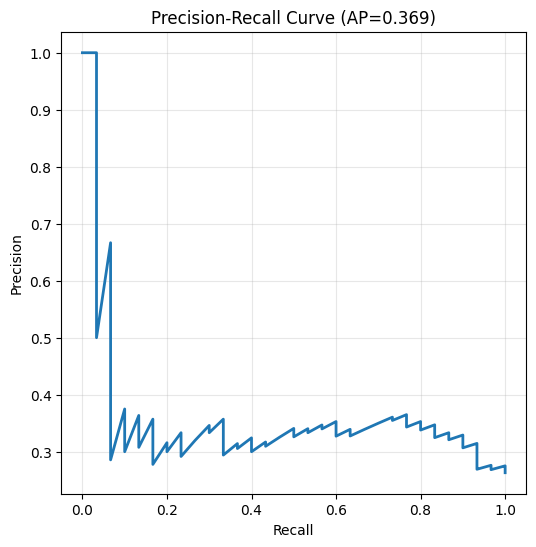

In [ ]:
prec, rec, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)
print("Average Precision (AP):", ap)

plt.figure(figsize=(6,6))
plt.plot(rec, prec, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP={ap:.3f})")
plt.grid(alpha=0.3)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step
Misclassified: 30


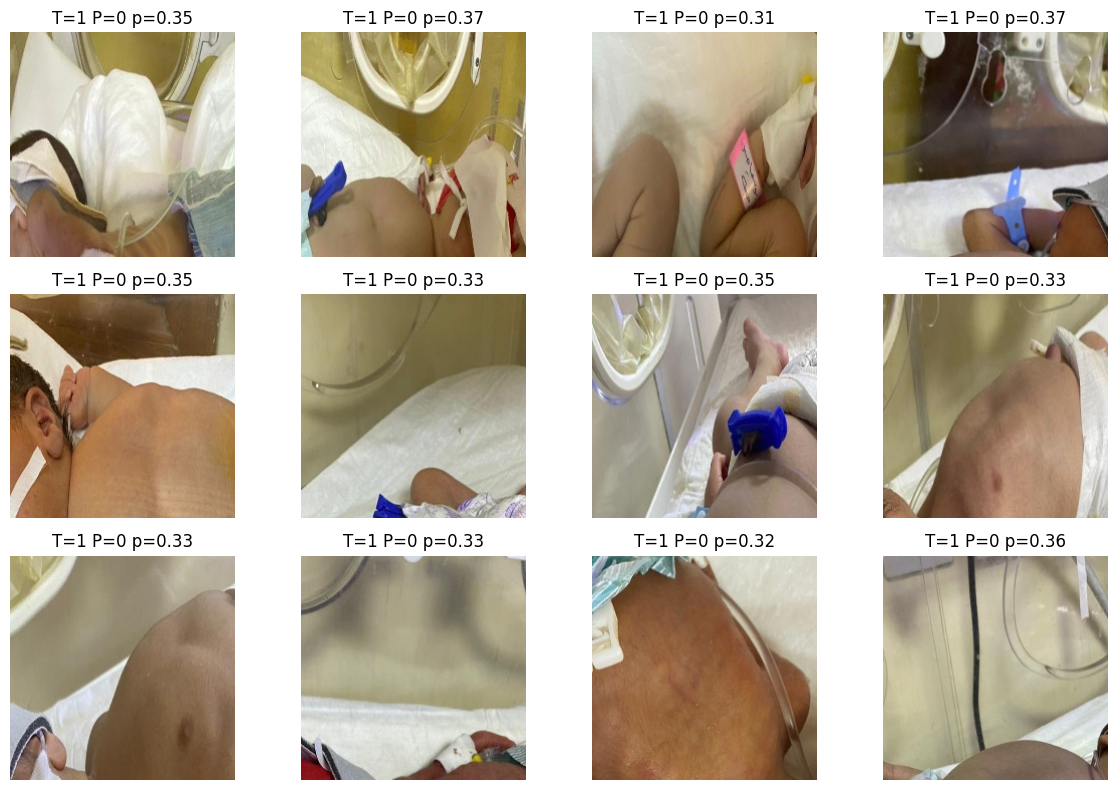

In [ ]:
# Load test file paths (from directory) for visualization
test_dir = os.path.join(OUT_ROOT, "test")
test_files = []
test_labels = []
for cls in ["0","1"]:
    files = sorted(glob.glob(os.path.join(test_dir, cls, "*")))
    test_files += files
    test_labels += [int(cls)] * len(files)

# Predict again on raw files (for index mapping)
def read_img(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype(np.float32)/255.0

X = np.stack([read_img(p) for p in test_files], axis=0)
prob = model.predict(X).ravel()
pred = (prob >= 0.5).astype(int)
true = np.array(test_labels)

mis_idx = np.where(pred != true)[0]
print("Misclassified:", len(mis_idx))

# show up to 12
show_n = min(12, len(mis_idx))
plt.figure(figsize=(12,8))
for i in range(show_n):
    idx = mis_idx[i]
    plt.subplot(3,4,i+1)
    plt.imshow((X[idx]*255).astype(np.uint8))
    plt.axis("off")
    plt.title(f"T={true[idx]} P={pred[idx]} p={prob[idx]:.2f}")
plt.tight_layout()
plt.show()